In [1]:
!pip install pacmap

  Using cached pacmap-0.7.3-py3-none-any.whl.metadata (12 kB)
  Using cached annoy-1.17.3.tar.gz (647 kB)
  Preparing metadata (setup.py) ... done
Using cached pacmap-0.7.3-py3-none-any.whl (18 kB)
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-macosx_11_0_arm64.whl size=57954 sha256=7b981af1fd776adaebb2d28e8eb10d1db2db2cd46737f6c3230ccecb20a0559b
  Stored in directory: /Users/nethanshaik/Library/Caches/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [5]:
import numpy as np
import pandas as pd
import pacmap

In [6]:
data = pd.read_csv('/Users/nethanshaik/Desktop/final_year_project/project/dl-on-multiomics/Combined_Omics_Mutated_Genes_Dataset.csv')

In [7]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [8]:
data.head()

,GE_FOXA1,GE_BRAF,GE_SPOP,GE_NKX3-1,GE_ZMYM3,GE_ATM,GE_CTNNB1,CNA_FOXA1,CNA_BRAF,CNA_SPOP,...,MutSig_(Q-value)_TP53,MutSig_(Q-value)_SPOP,MutSig_(Q-value)_FOXA1,Mut_TP53,Mut_SPOP,Mut_FOXA1,Freq_TP53,Freq_SPOP,Freq_FOXA1,Gleason_Score
0,0.684537,0.401258,0.432423,0.576310,0.710846,0.487204,0.822607,0.370714,0.220151,0.386164,...,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0
1,0.593167,0.370666,0.651981,0.697055,0.645458,0.426688,0.781097,0.354495,0.204106,0.403145,...,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0
2,0.687300,0.405120,0.258006,0.582047,0.787792,0.603989,0.757727,0.358202,0.204342,0.398113,...,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0
3,0.379166,0.169027,0.509185,0.622602,0.598594,0.175336,0.705212,0.351251,0.207645,0.381761,...,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,1
4,0.555879,0.290225,0.409782,0.722197,0.757623,0.531428,0.745461,0.358202,0.207645,0.396226,...,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0.003448,0


In [9]:
data.shape

(290, 32)

In [10]:
x = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

In [11]:
x.shape

(290, 31)

In [12]:
y.shape

(290,)

In [100]:
pac = pacmap.PaCMAP(n_components=2, n_neighbors = 10, MN_ratio=1.0, FP_ratio=1.0)

In [101]:
X_PAC = pac.fit_transform(x)

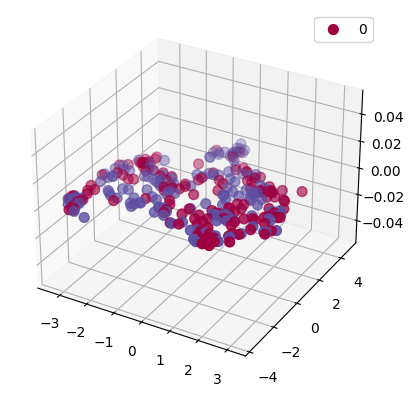

In [102]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fid = plt.figure()
ax = fid.add_subplot(111, projection='3d')
ax.scatter(X_PAC[:,0],X_PAC[:,1],cmap="Spectral",c=data['Gleason_Score'],s=50)
plt.legend(data['Gleason_Score'])
plt.show()

In [34]:
import plotly.express as px

fig = px.scatter_3d(
    X_PAC,
    x=X_PAC[:,0],
    y=X_PAC[:,1],
    z=X_PAC[:,2],
    color=data['Gleason_Score'],  # Color points based on Gleason_Score
    title="Interactive 3D PacMAP Plot",
    labels={'color': 'Gleason Score'},
    opacity=0.8,
    color_continuous_scale='Spectral'  # Same color map as your Matplotlib version
)

# Show the plot
fig.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [104]:
x_train,x_test,y_train,y_test = train_test_split(X_PAC, y, test_size = 0.3, random_state = 42)

In [105]:
classifier = DecisionTreeClassifier(random_state=42)

In [106]:
classifier.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [107]:
y_pred = classifier.predict(x_test)
print(f"Accuracy Report: {accuracy_score(y_test,y_pred)}")
print(f"Classification Report: {classification_report(y_test, y_pred)}")

Accuracy Report: 0.5287356321839081
Classification Report:               precision    recall  f1-score   support

           0       0.54      0.50      0.52        44
           1       0.52      0.56      0.54        43

    accuracy                           0.53        87
   macro avg       0.53      0.53      0.53        87
weighted avg       0.53      0.53      0.53        87



In [108]:
from sklearn.ensemble import RandomForestClassifier

In [109]:
rand = RandomForestClassifier(random_state=42)

In [110]:
rand.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [111]:
y_pred = rand.predict(x_test)

In [112]:
print(f"Accuracy Report: {accuracy_score(y_test,y_pred)}")
print(f"Classification Report: {classification_report(y_test, y_pred)}")

Accuracy Report: 0.5747126436781609
Classification Report:               precision    recall  f1-score   support

           0       0.59      0.52      0.55        44
           1       0.56      0.63      0.59        43

    accuracy                           0.57        87
   macro avg       0.58      0.58      0.57        87
weighted avg       0.58      0.57      0.57        87



In [113]:
log_reg = LogisticRegression(random_state=42)

In [114]:
log_reg.fit(x_train,y_train)

LogisticRegression(random_state=42)

In [115]:
y_pred = log_reg.predict(x_test)

In [116]:
print(f"accuracy_score: {accuracy_score(y_test, y_pred)}")
print(f"Classification Report: {classification_report(y_test, y_pred)}")

accuracy_score: 0.6206896551724138
Classification Report:               precision    recall  f1-score   support

           0       0.64      0.57      0.60        44
           1       0.60      0.67      0.64        43

    accuracy                           0.62        87
   macro avg       0.62      0.62      0.62        87
weighted avg       0.62      0.62      0.62        87

